# Simple Synthetic Experiment Datamodule Demo

This notebook shows how to:
- load the simple-mode meta-study configuration,
- instantiate an `AICMECompartmentsDataModule`,
- sample one batch list from `get_synthetic_experiment_dataloader(...)`, and
- plot the resulting simple-mode `AICMECompartmentsDataBatch` objects.

The simple loader path keeps context and target from the same simple simulation draw while using the fixed regular grid observation strategy for targets.


In [2]:
from __future__ import annotations

import sys
from pathlib import Path
from pprint import pprint

import torch

%matplotlib inline

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "pff").exists():
    for candidate in [PROJECT_DIR, *PROJECT_DIR.parents]:
        if (candidate / "pff").exists() and (candidate / "config_files").exists():
            PROJECT_DIR = candidate
            break

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from pff import config_dir
from pff.config_classes.data_config import (
    MetaDosingConfig,
    ObservationsConfig,
    SimpleMetaStudyConfig,
)
from pff.config_classes.node_pk_config import NodePKExperimentConfig
from pff.data.datasets.aicme_datasets import AICMECompartmentsDataModule
from pff.utils.plots.databatch_plot import plot_list_aicme_databatch

torch.manual_seed(7)


In [4]:
# Simple configuration paths --------------------------------------------------
EXPERIMENT_DIR = config_dir / "experiment_configs" / "UAI" / "Submission" / "flow-pk-generate"
META_STUDY_CONFIG_PATH = EXPERIMENT_DIR / "simple.meta_study.yaml"
DOSING_CONFIG_PATH = EXPERIMENT_DIR / "base.dosing.yaml"
OBSERVATIONS_CONFIG_PATH = EXPERIMENT_DIR / "base.observations.yaml"

meta_study_config = SimpleMetaStudyConfig.from_yaml(META_STUDY_CONFIG_PATH)
meta_dosing_config = MetaDosingConfig.from_yaml(DOSING_CONFIG_PATH)
context_observations = ObservationsConfig.from_yaml(
    OBSERVATIONS_CONFIG_PATH,
    section="context_observations",
)
target_observations = ObservationsConfig.from_yaml(
    OBSERVATIONS_CONFIG_PATH,
    section="target_observations",
)

cfg = NodePKExperimentConfig(
    meta_study=meta_study_config,
    dosing=meta_dosing_config,
    context_observations=context_observations,
    target_observations=target_observations,
)

# Notebook-friendly runtime knobs.
cfg.mix_data.test_empirical_datasets = []
cfg.train.num_workers = 0
cfg.train.persistent_workers = False
cfg.train.batch_size = 2
cfg.mix_data.n_of_permutations = 1
cfg.mix_data.train_size = 4
cfg.mix_data.val_size = 2
cfg.mix_data.test_size = 2

dm = AICMECompartmentsDataModule(cfg)
dm.prepare_data()

print("Simple meta-study config loaded from:")
print(META_STUDY_CONFIG_PATH)
print()
print("Simple meta-study summary:")
pprint({
    "simple_mode": meta_study_config.simple_mode,
    "num_individuals": meta_study_config.num_individuals,
    "num_individuals_range": meta_study_config.num_individuals_range,
    "time_start": meta_study_config.time_start,
    "time_stop": meta_study_config.time_stop,
    "time_num_steps": meta_study_config.time_num_steps,
    "p1": meta_study_config.p1,
})


Simple meta-study config loaded from:
/home/cesarali/Pharma/pff/config_files/experiment_configs/UAI/Submission/flow-pk-generate/simple.meta_study.yaml

Simple meta-study summary:
{'num_individuals': 20,
 'num_individuals_range': (20, 20),
 'p1': 0.0,
 'simple_mode': True,
 'time_num_steps': 40,
 'time_start': 0.0,
 'time_stop': 24.0}


Returned 2 databatches from the simple-mode loader
Permutation 0: context_obs=(2, 20, 15, 1), target_obs=(2, 40, 15, 1), target_rem_sim_mask_any=False, study_names=['', '']
Permutation 1: context_obs=(2, 20, 15, 1), target_obs=(2, 40, 15, 1), target_rem_sim_mask_any=False, study_names=['', '']


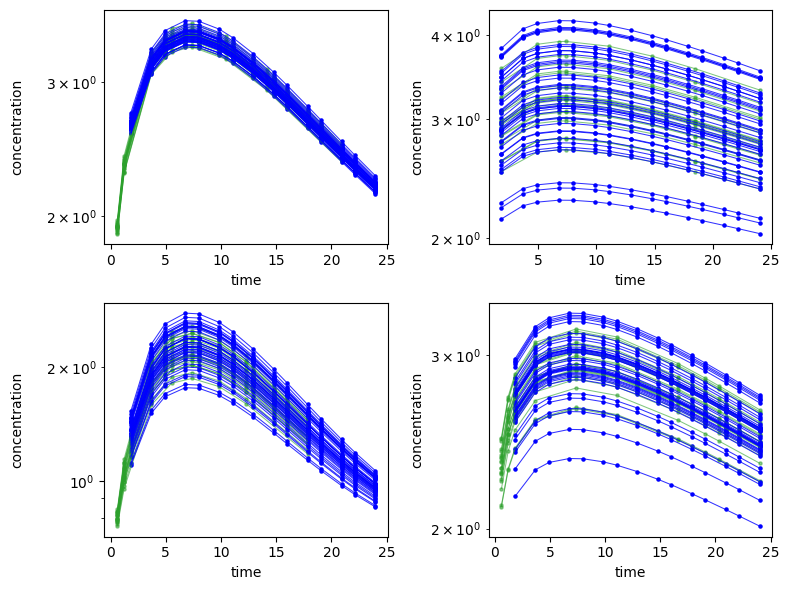

In [7]:
%matplotlib inline 
# Datamodule helper: simple synthetic experiment dataloader -------------------
N_TARGETS = 40
N_DOSINGS = 2
DATASET_SIZE = 3

simple_batch_list = dm.get_synthetic_experiment_dataloader(
    n_targets=N_TARGETS,
    n_dosings=N_DOSINGS,
    dosing_mode="diverse_dosing",
    dataset_size=DATASET_SIZE,
)

simple_batch_list = next(iter(simple_batch_list))
print(f"Returned {len(simple_batch_list)} databatches from the simple-mode loader")

for p, batch in enumerate(simple_batch_list):
    print(
        f"Permutation {p}: context_obs={tuple(batch.context_obs.shape)}, "
        f"target_obs={tuple(batch.target_obs.shape)}, "
        f"target_rem_sim_mask_any={bool(batch.target_rem_sim_mask.any())}, "
        f"study_names={batch.study_name}"
    )

_ = plot_list_aicme_databatch(
    simple_batch_list,
    number_of_rows=2,
    number_of_columns=2,
    log_scale=True,
    file_name=None,
)
